In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Load model
da_model_ac=xr.open_dataarray("initial_param_acidity.nc")
da_model_no_t=xr.open_dataarray('initial_param_no_transport.nc')
# Load clim obs
df_obs=pd.read_csv("/data/rd_exchange/sroyer/SEAPOPYM/monthly_clim_pteropod_1998_2020_v3.csv")

In [3]:
da_model_ac

<xarray.DataArray 'biomass' (functional_group: 1, time: 365, latitude: 1,
                             longitude: 1)> Size: 3kB
[365 values with dtype=float64]
Coordinates:
  * time              (time) datetime64[ns] 3kB 2001-01-01 ... 2001-12-31
  * latitude          (latitude) int64 8B 0
  * longitude         (longitude) int64 8B 0
  * functional_group  (functional_group) int64 8B 0
Attributes:
    long_name:    biomass
    units:        kilogram / meter ** 2
    description:  The biomass of the recruited individuals.

In [4]:
df_obs

,month,pteropod_biomass_gm2_mean,pteropod_biomass_gm2_std,pteropod_biomass_median,non_nan_count
0,1,0.033287,0.260625,0.037669,5
1,2,0.017922,0.410406,0.015123,37
2,3,0.009675,0.433482,0.009227,5
3,4,0.087757,0.344764,0.057290,5
4,5,0.143989,0.715110,0.145701,68
5,6,0.138077,0.736781,0.122413,46
6,7,0.036432,0.808265,0.032364,29
7,8,0.033574,0.848848,0.025883,42
8,9,0.028515,0.627508,0.023482,47
9,10,0.019716,0.484149,0.024265,21


In [5]:
da_model_ac

<xarray.DataArray 'biomass' (functional_group: 1, time: 365, latitude: 1,
                             longitude: 1)> Size: 3kB
[365 values with dtype=float64]
Coordinates:
  * time              (time) datetime64[ns] 3kB 2001-01-01 ... 2001-12-31
  * latitude          (latitude) int64 8B 0
  * longitude         (longitude) int64 8B 0
  * functional_group  (functional_group) int64 8B 0
Attributes:
    long_name:    biomass
    units:        kilogram / meter ** 2
    description:  The biomass of the recruited individuals.

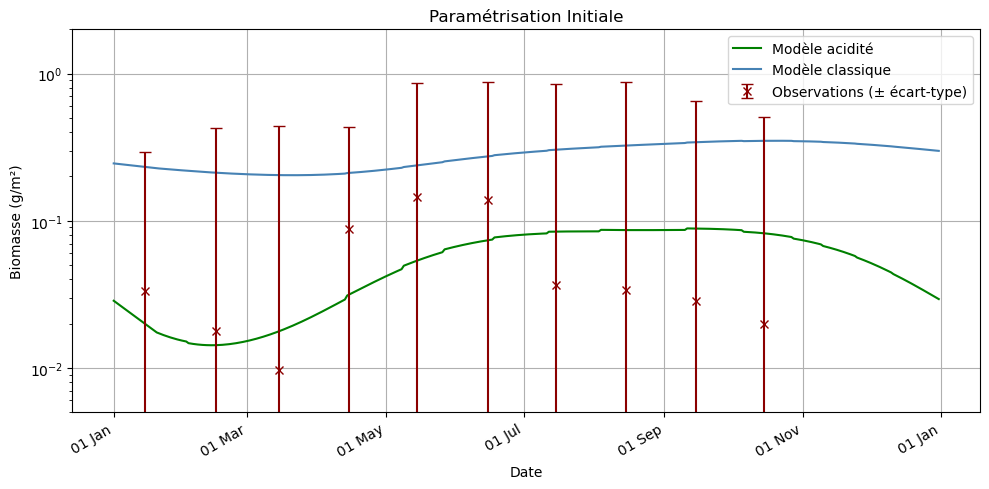

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# Générer les dates du 15 de chaque mois
dates_obs = pd.date_range("2001-01-01", "2001-10-01", freq="MS") + pd.Timedelta(days=14)

# Tracer
plt.figure(figsize=(10, 5))

# Tracer la courbe du modèle
plt.plot(da_model_ac.time.values, da_model_ac.isel(latitude=0,longitude=0,functional_group=0).values*10**3, label="Modèle acidité", color="green")
plt.plot(da_model_no_t.time.values, da_model_no_t.isel(latitude=0,longitude=0,functional_group=0).values*10**3, label="Modèle classique", color="steelblue")
# Tracer les croix des observations (pas de ligne)
# plt.plot(dates_obs, df_obs['pteropod_biomass_gm2_mean'], 
#          'x', color='darkred', label="Climatologie des Observations", markersize=8)
# Récupération des moyennes et des incertitudes
mean = df_obs['pteropod_biomass_gm2_mean'].values
std = df_obs['pteropod_biomass_gm2_std'].values

# Correction : empêcher les barres d'erreur de descendre sous zéro
err_low = np.minimum(std, mean)  # si std > mean, la barre basse s'arrête à 0
err_up = std  # on garde la valeur normale pour la barre supérieure
asymmetric_error = [err_low, err_up]

# Tracer les observations avec barres d’erreur corrigées
plt.errorbar(
    dates_obs,
    mean,
    yerr=asymmetric_error,
    fmt='x',
    color='darkred',
    ecolor='darkred',
    capsize=4,
    label="Observations (± écart-type)"
)

# Mise en forme
plt.xlabel("Date")
plt.ylabel("Biomasse (g/m²)")
plt.title("Paramétrisation Initiale")
plt.legend()
plt.grid(True)
plt.yscale('log')
plt.ylim(0.005,2)

# Format de date plus lisible
# Mise en forme de l’axe des dates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))  # Affiche "15 jan", "15 fév", etc.
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()


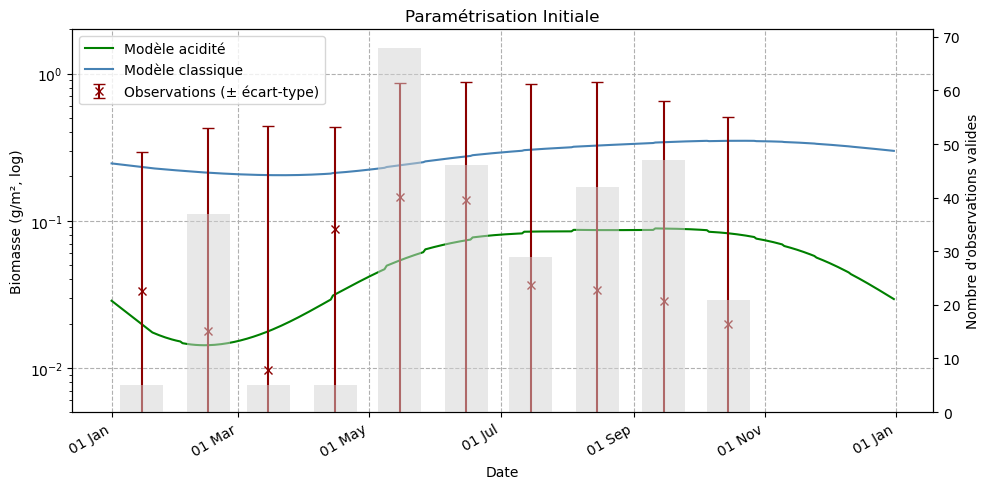

In [7]:

# Générer les dates du 15 de chaque mois
dates_obs = pd.date_range("2001-01-01", "2001-10-01", freq="MS") + pd.Timedelta(days=14)

mean = df_obs['pteropod_biomass_gm2_mean'].values
std = df_obs['pteropod_biomass_gm2_std'].values
count = df_obs['non_nan_count'].values

# Création de la figure
fig, ax1 = plt.subplots(figsize=(10, 5))

# Tracer le nombre de points valides en barres grises
ax2 = ax1.twinx()
bar_width = 20  # largeur des barres en jours
ax2.bar(dates_obs, count, width=bar_width, color='lightgray', alpha=0.5)
ax2.set_ylabel("Nombre d'observations valides")

# Tracer la courbe du modèle
ax1.plot(da_model_ac.time.values, da_model_ac.isel(latitude=0,longitude=0,functional_group=0).values*10**3, label="Modèle acidité", color="green")
ax1.plot(da_model_no_t.time.values, da_model_no_t.isel(latitude=0,longitude=0,functional_group=0).values*10**3, label="Modèle classique", color="steelblue")



# Correction : empêcher les barres d'erreur de descendre sous zéro
err_low = np.minimum(std, mean)  # si std > mean, la barre basse s'arrête à 0
err_up = std  # on garde la valeur normale pour la barre supérieure
asymmetric_error = [err_low, err_up]

# Tracer les observations avec barres d’erreur corrigées
ax1.errorbar(
    dates_obs,
    mean,
    yerr=asymmetric_error,
    fmt='x',
    color='darkred',
    ecolor='darkred',
    capsize=4,
    label="Observations (± écart-type)"
)

# Mise en forme

ax1.set_yscale('log')
ax1.set_xlabel("Date")
ax1.set_ylabel("Biomasse (g/m², log)")
ax1.set_title("Paramétrisation Initiale")
ax1.grid(True, linestyle='--')
ax1.legend(loc='upper left')
ax1.set_ylim(0.005,2)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
fig.autofmt_xdate()


plt.tight_layout()
plt.show()
